In [2]:
import pandas as pd
import os
import json

file_root="/u01/fengxiaobin/Projects/脾胃病模型/exam_projects/TCWM-BEST4SDT-main/results/01think"
file_name=os.listdir(file_root)
model_results_dict={}
for filename in file_name:
    file_path_abs=os.path.join(file_root, filename,"detailed_results.json")
    with open(file_path_abs, "r") as f:
        datas=json.load(f)
    rest_list_dict=datas['final_scores']['SDT_task']['dimension_scores']
    model_results_dict[filename]=[rest_list_dict[k] for k in rest_list_dict]

In [3]:
import pandas as pd
import os
import json

file_root="/u01/fengxiaobin/Projects/脾胃病模型/exam_projects/TCWM-BEST4SDT-main/results/01think"
file_name=os.listdir(file_root)
model_results_dict={}
for filename in file_name:
    file_path_abs=os.path.join(file_root, filename,"detailed_results.json")
    with open(file_path_abs, "r") as f:
        datas=json.load(f)
    rest_list_dict=datas['final_scores']['SDT_task']['dimension_scores']
    model_results_dict[filename]=[rest_list_dict[k] for k in rest_list_dict]
    
    

file_root="/u01/fengxiaobin/Projects/脾胃病模型/exam_projects/TCWM-BEST4SDT-main/results/02nothink"
file_name=os.listdir(file_root)
model_results_dict_nocot={}
for filename in file_name:
    file_path_abs=os.path.join(file_root, filename,"detailed_results.json")
    with open(file_path_abs, "r") as f:
        datas=json.load(f)
    rest_list_dict=datas['final_scores']['SDT_task']['dimension_scores']
    model_results_dict_nocot[filename]=[rest_list_dict[k] for k in rest_list_dict]

In [4]:
print(len(model_results_dict.keys()))
model_results_dict
for l in model_results_dict:
    print(l,len(model_results_dict[l]))

9
GPT-5.2-2025-12-11 10
Baichuan-M3 10
DeepSeek-v3.2-Thinking 10
Ours 10
Qwen3-14B 10
HuatuoGPT-o1 10
Gemini-3 10
GLM-4.5 10
Qwen3-32B 10


In [5]:
print(len(model_results_dict_nocot))
for l in model_results_dict_nocot:
    print(l,len(model_results_dict_nocot[l]))

6
Zhongjing-LLaMA-lora 8
MMed-Llama-3-8B-EnIns 8
Ours 8
Sunsimiao-Qwen2-7B 8
BianCang-Qwen2.5-14B-Instruct 8
ShizhenGPT-32B-LLM 8


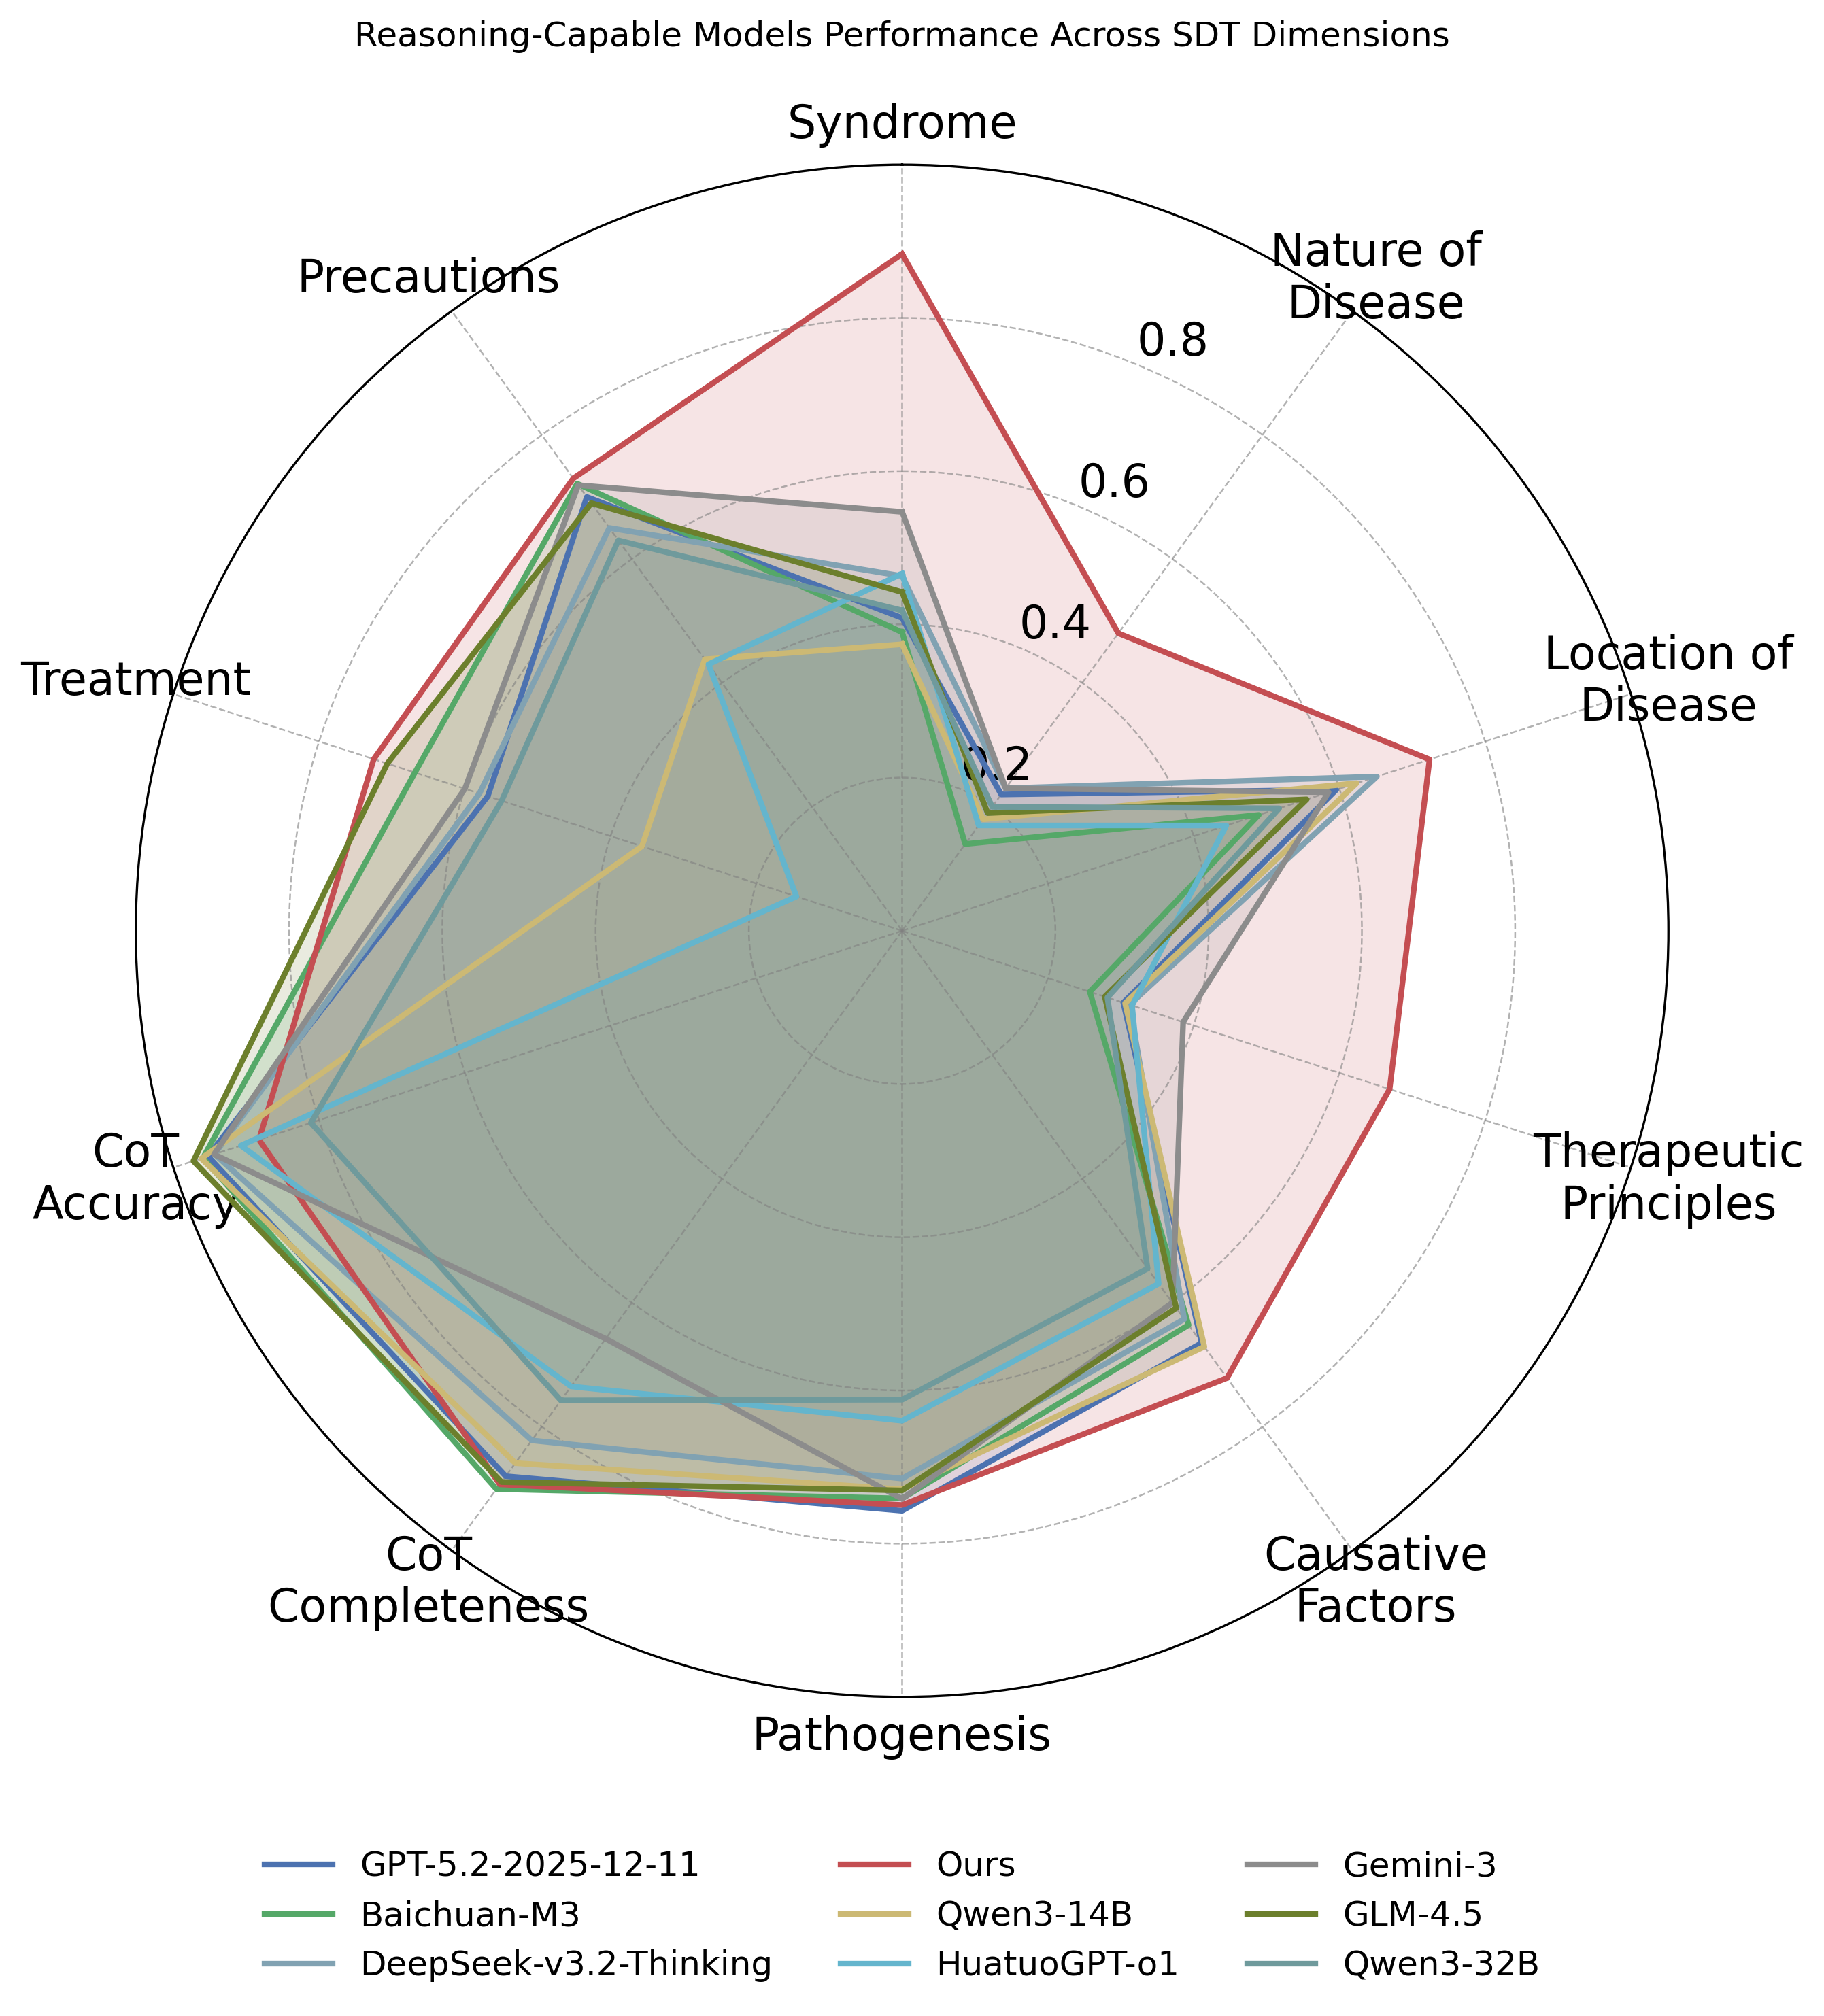

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# =============================
# 1. 维度名称（顺时针）
# =============================
labels = [
    "Syndrome",
    "Nature of\nDisease",
    "Location of\nDisease",
    "Therapeutic\nPrinciples",
    "Causative\nFactors",
    "Pathogenesis",
    "CoT\nCompleteness",
    "CoT\nAccuracy",
    "Treatment",
    "Precautions"
]

num_vars = len(labels)

# =============================
# 2. 模型数据（示例，替换为你自己的）
#    每个列表长度必须 == num_vars
# =============================
# model_scores = {
#     "Baseline LLM": [
#         0.62, 0.60, 0.65, 0.68, 0.66, 0.70,
#         0.64, 0.61, 0.58, 0.55, 0.60,
#         0.72, 0.70, 0.63, 0.66, 0.62
#     ]
# }
model_scores=model_results_dict
# =============================
# 3. 雷达图基础设置
# =============================
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles = np.concatenate([angles, [angles[0]]])  # 闭合

# 提高分辨率：设置更大的图像尺寸和更高的DPI
plt.figure(figsize=(10, 10), dpi=300)  # 增大尺寸和DPI
ax = plt.subplot(111, polar=True)

# 起始角度设为正上方，顺时针
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# =============================
# 4. 坐标轴 & 网格
# =============================
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=16)

ax.set_ylim(0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], fontsize=16)
ax.grid(color="gray", linestyle="--", linewidth=0.6, alpha=0.6)

# =============================
# 5. 绘制每个模型
# =============================
colors =["#4C72B0", "#55A868", "#81a2B2", "#C44E52", "#CCB974", "#64B5CD", "#8C8C8C","#6C7F2C","#6f9a9C"]


for (model_name, scores), color in zip(model_scores.items(), colors):
    values = np.array(scores)
    values = np.concatenate([values, [values[0]]])  # 闭合

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=model_name,
        color=color
    )
    ax.fill(
        angles,
        values,
        color=color,
        alpha=0.15
    )

# =============================
# 6. 图例 & 标题
# =============================
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False,
    fontsize=12
)

plt.title(
    "Reasoning-Capable Models Performance Across SDT Dimensions",
    fontsize=12,
    pad=20
)

plt.tight_layout()
plt.show()


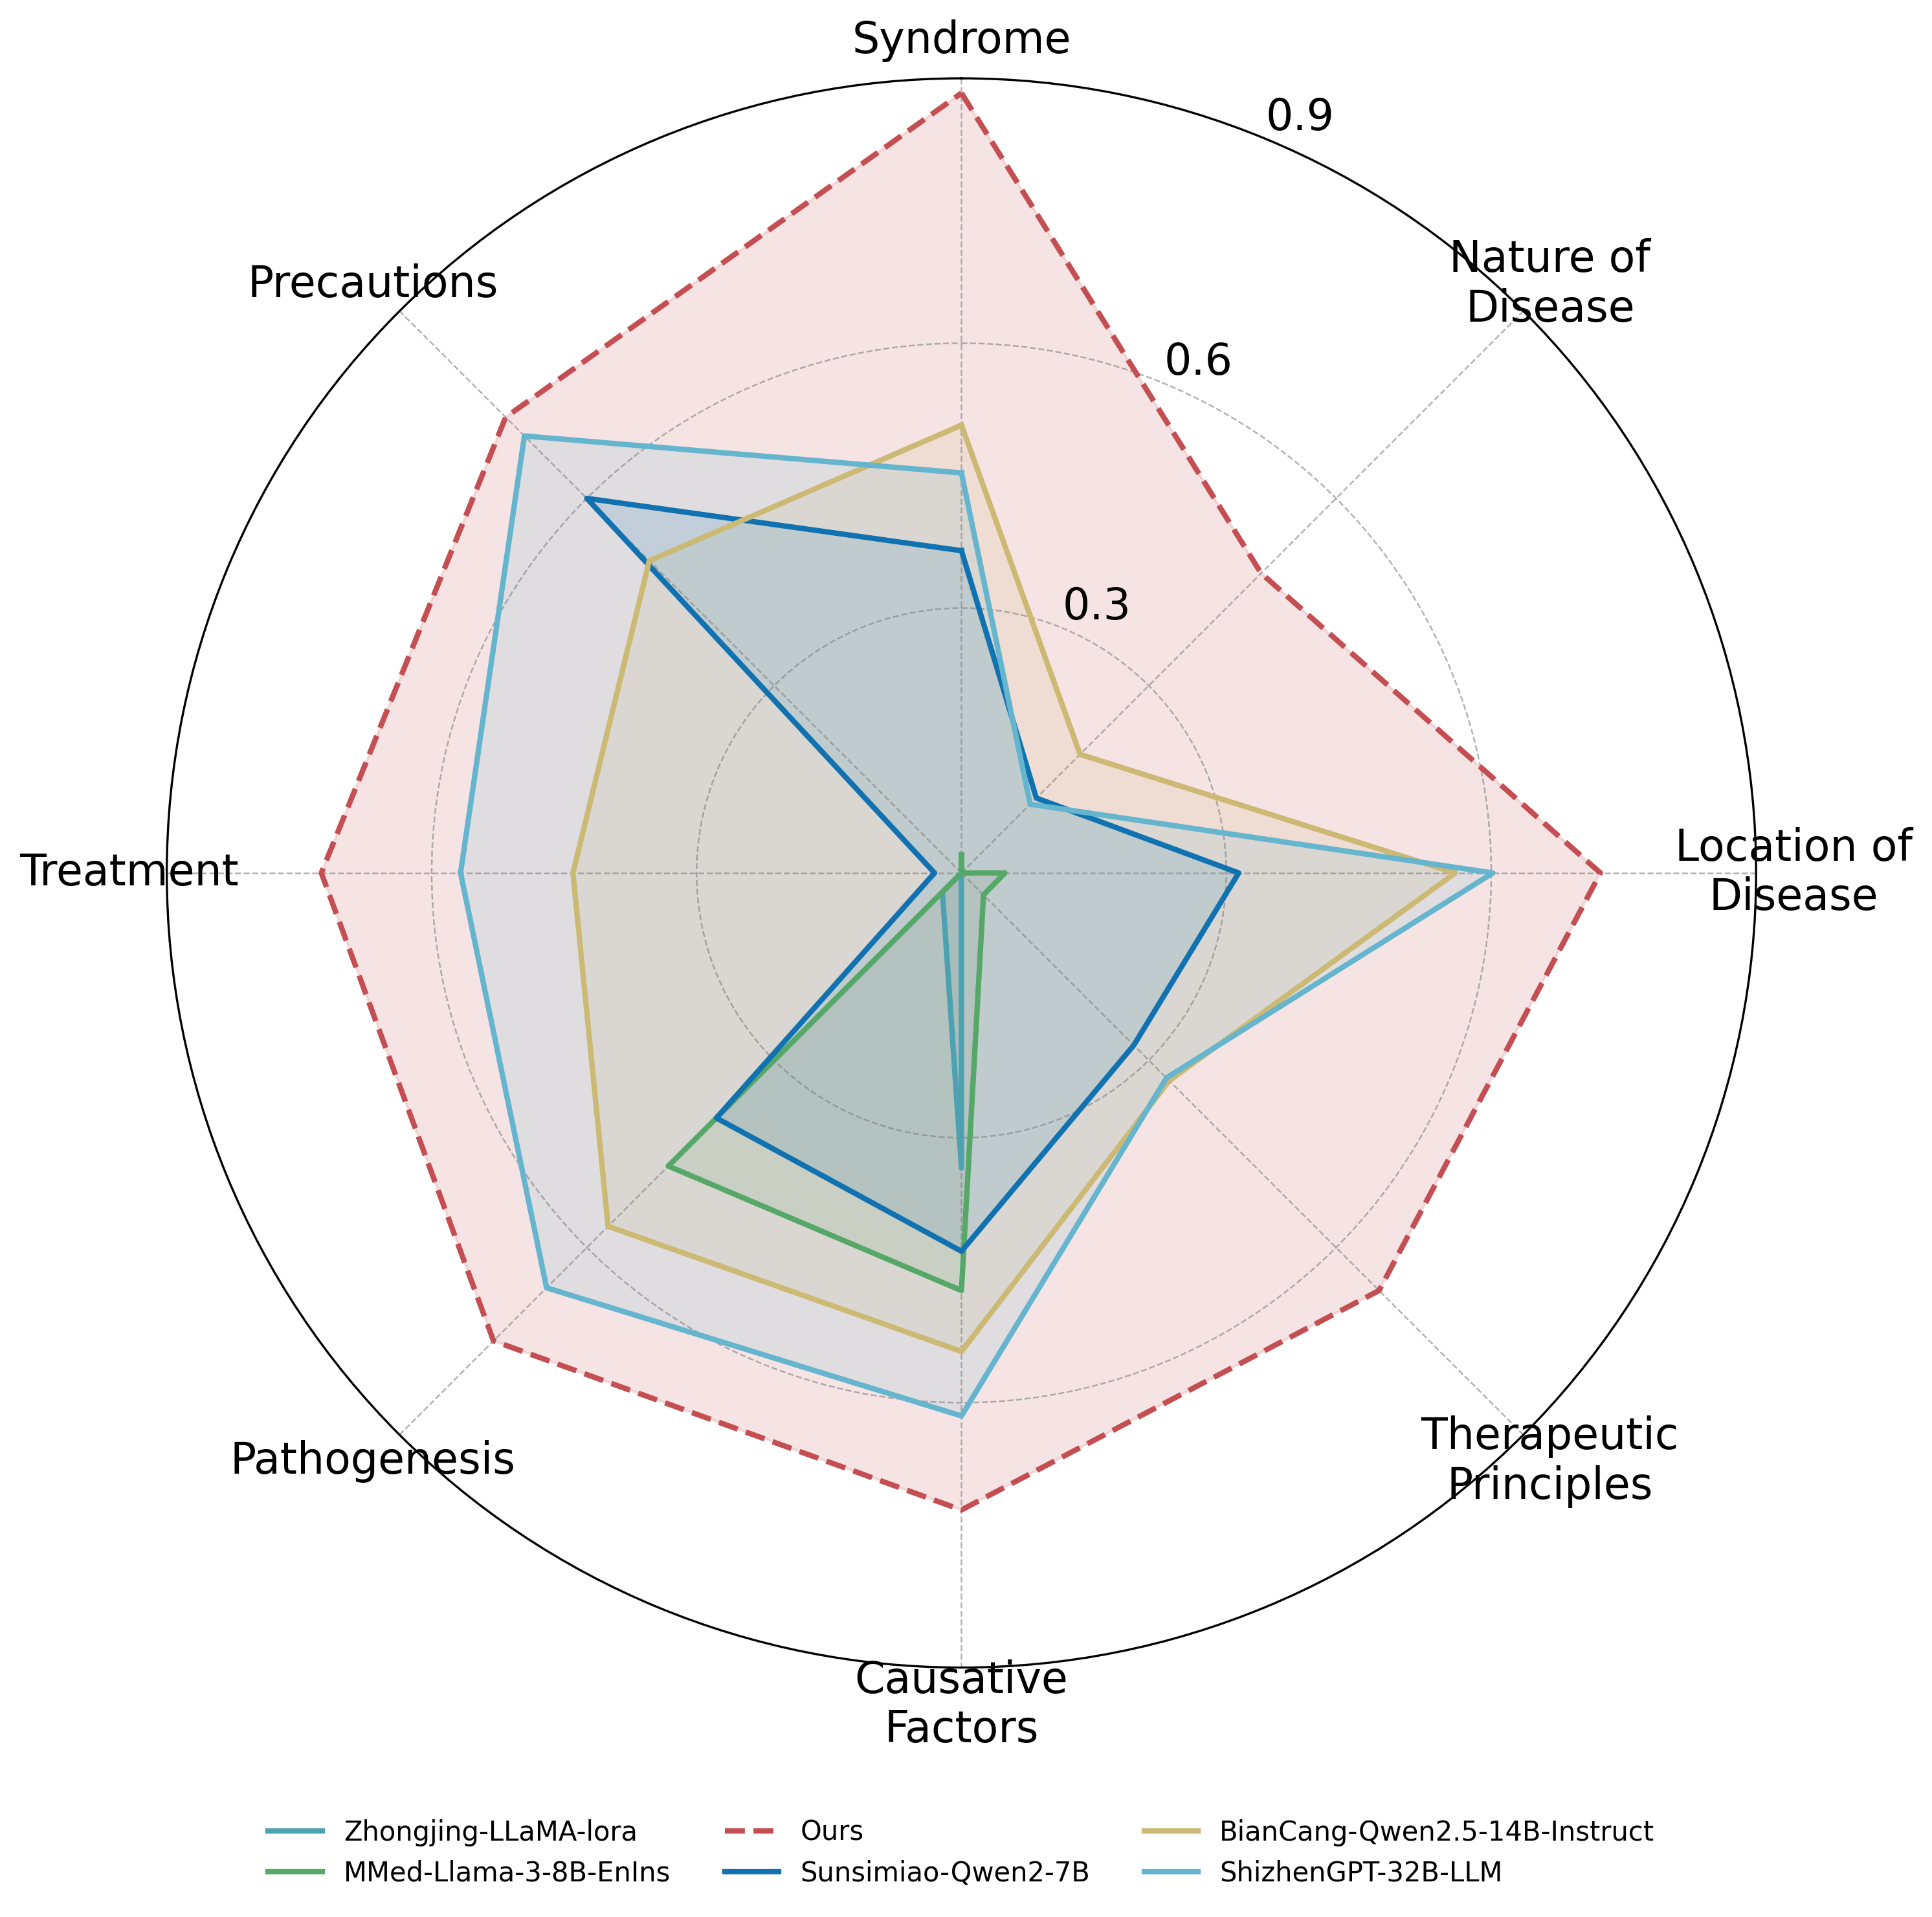

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# =============================
# 1. 维度名称（顺时针）
# =============================
labels = [
    "Syndrome",
    "Nature of\nDisease",
    "Location of\nDisease",
    "Therapeutic\nPrinciples",
    "Causative\nFactors",
    "Pathogenesis",
    "Treatment",
    "Precautions"
]

num_vars = len(labels)

# =============================
# 2. 模型数据（示例，替换为你自己的）
#    每个列表长度必须 == num_vars
# =============================
# model_scores = {
#     "Baseline LLM": [
#         0.62, 0.60, 0.65, 0.68, 0.66, 0.70,
#         0.64, 0.61, 0.58, 0.55, 0.60,
#         0.72, 0.70, 0.63, 0.66, 0.62
#     ],
#     "Instruction-tuned": [
#         0.70, 0.68, 0.72, 0.75, 0.73, 0.77,
#         0.70, 0.68, 0.63, 0.60, 0.66,
#         0.82, 0.78, 0.71, 0.74, 0.70
#     ],
#     "Ours (CoT-enhanced)": [
#         0.78, 0.75, 0.80, 0.83, 0.82, 0.86,
#         0.79, 0.77, 0.70, 0.68, 0.74,
#         0.91, 0.88, 0.80, 0.83, 0.79
#     ]
# }
model_scores=model_results_dict_nocot
# =============================
# 3. 雷达图基础设置
# =============================
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles = np.concatenate([angles, [angles[0]]])  # 闭合

# 提高分辨率：设置更大的图像尺寸和更高的DPI
plt.figure(figsize=(10, 10), dpi=300)  # 增大尺寸和DPI
ax = plt.subplot(111, polar=True)


# 起始角度设为正上方，顺时针
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# =============================
# 4. 坐标轴 & 网格
# =============================
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=16)

ax.set_ylim(0, 0.9)
# ax.set_yticks([0.2, 0.4, 0.6, 0.8, 0.9])
ax.set_yticks([0.3, 0.6, 0.9])
ax.set_yticklabels(["0.3", "0.6", "0.9"], fontsize=16)
# ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "0.9"], fontsize=16)
ax.grid(color="gray", linestyle="--", linewidth=0.6, alpha=0.6)

# =============================
# 5. 绘制每个模型
# =============================
colors =["#4Ca2B0", "#55A868", "#C44E52", "#1172B2", "#CCB974","#64B5CD"]


for idx,((model_name, scores), color) in enumerate(zip(model_scores.items(), colors)):
    values = np.array(scores)
    values = np.concatenate([values, [values[0]]])  # 闭合

     # 判断是否为第三个模型（索引从0开始，所以第三个是idx == 2）
    if idx == 2:
        linestyle = '--'  # 虚线
        linewidth = 2   # 可选：虚线稍微加粗一点，更明显
    else:
        linestyle = '-'
        linewidth = 2

    ax.plot(
        angles,
        values,

        label=model_name,
        linewidth=linewidth,
        linestyle=linestyle, 
        color=color
    )
    ax.fill(
        angles,
        values,
        color=color,
        alpha=0.15
    )

# =============================
# 6. 图例 & 标题
# =============================
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False,
    fontsize=10
)

plt.title(
    "",
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()
